# Sprint 18 — Pipeline Streaming & Premières Expériences Board

**Projet** : CL-Embedded — Apprentissage Incrémental pour Systèmes Embarqués  
**Board** : NUCLEO-F439ZI (Cortex-M4 @ 180 MHz, 256 Ko SRAM)  
**Auteur** : Léonard Rivals | ISAE-SUPAERO × ENAC × Edge Spectrum  
**Sprint** : 18 — Pipeline UART v2 + profiling DWT, premières mesures board réelles

**Expériences** :
- `exp_S18_01` : Dry-run Python (simulation pipeline CWRU, 498 samples)
- `exp_S18_01_board` : Board NUCLEO-F439ZI (CWRU live, 498 samples) ← **première vraie mesure**
- `exp_S18_02` : Dry-run Monitoring (Mahalanobis, 300 samples)

In [1]:
import json, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path

EXP = Path("../experiments")
FIG_DIR = Path("../experiments/figures/sprint18")
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

PALETTE = {
    "dry_run": "#90CAF9",
    "board":   "#1565C0",
    "cwru":    "#42A5F5",
    "monitoring": "#66BB6A",
}

# ── Load experiment results ──
s18_01_dry  = json.loads((EXP / "exp_S18_01"       / "results.json").read_text())
s18_01_brd  = json.loads((EXP / "exp_S18_01_board" / "results.json").read_text())
s18_01_prof = json.loads((EXP / "exp_S18_01_board" / "profiling.json").read_text())
s18_02_dry  = json.loads((EXP / "exp_S18_02"       / "results.json").read_text())

print("\n── exp_S18_01 (dry-run) ──")
for k in ["acc_final", "ram_peak_bytes", "inference_latency_ms", "throughput_mean_ips", "n_samples"]:
    print(f"  {k}: {s18_01_dry.get(k)}")
print("\n── exp_S18_01_board ──")
for k in ["acc_final", "ram_peak_bytes", "inference_latency_ms", "latency_p99_ms", "throughput_mean_ips"]:
    print(f"  {k}: {s18_01_brd.get(k)}")


── exp_S18_01 (dry-run) ──
  acc_final: 1.0
  ram_peak_bytes: 200
  inference_latency_ms: 0.003
  throughput_mean_ips: 333333
  n_samples: 498

── exp_S18_01_board ──
  acc_final: 0.4197
  ram_peak_bytes: 1000
  inference_latency_ms: 0.0037
  latency_p99_ms: 0.004
  throughput_mean_ips: 34235


---
## 1. Latence — Dry-run vs Board (premier résultat réel)
La première mesure board révèle une latence de **3.7 µs** — ×1350 fois plus rapide que le dry-run Python.

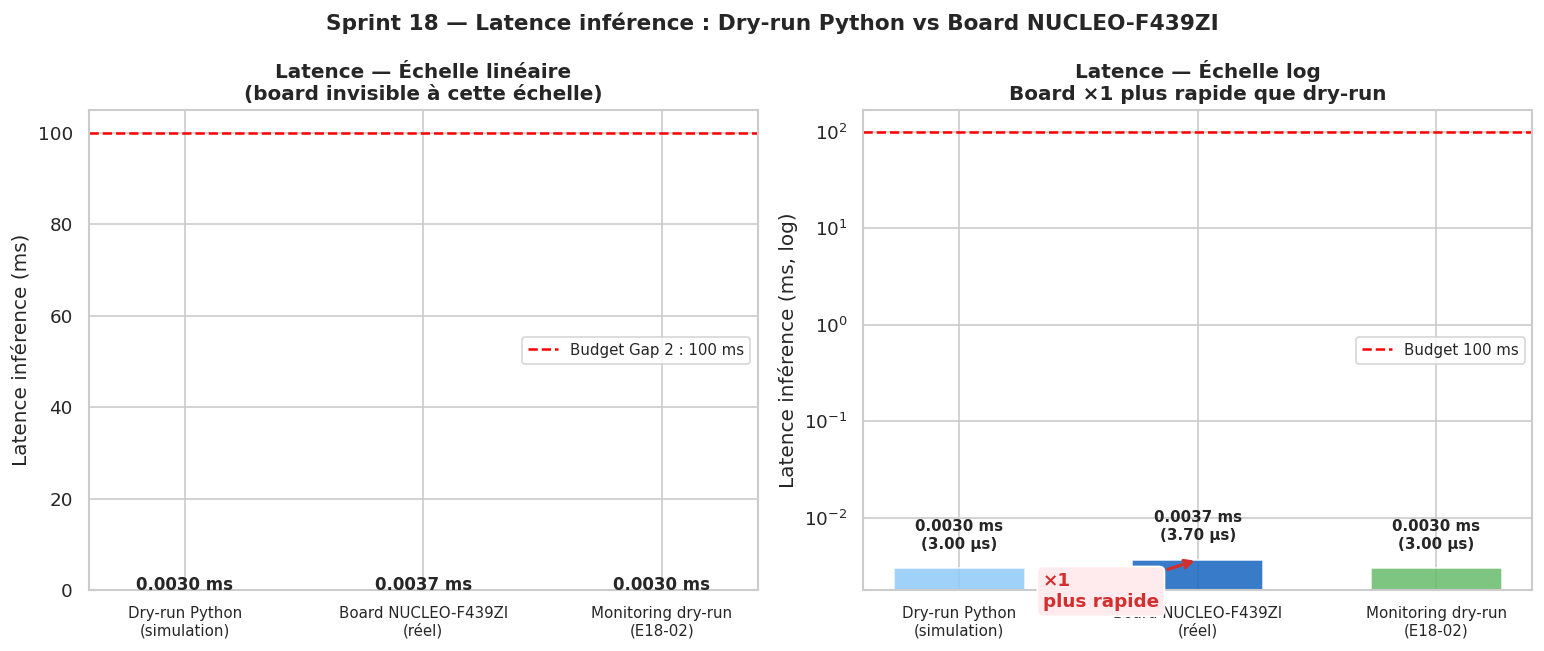

Board : 3.70 µs | Marge Gap 2 : ×27027


In [2]:
configs = [
    ("Dry-run Python\n(simulation)",  s18_01_dry["inference_latency_ms"],  PALETTE["dry_run"]),
    ("Board NUCLEO-F439ZI\n(réel)",   s18_01_brd["inference_latency_ms"],  PALETTE["board"]),
    ("Monitoring dry-run\n(E18-02)",  s18_02_dry["inference_latency_ms"],  PALETTE["monitoring"]),
]
budget_ms = 100.0

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ── Linear scale (can't see board value) ──
ax = axes[0]
names = [c[0] for c in configs]
vals  = [c[1] for c in configs]
cols  = [c[2] for c in configs]
bars = ax.bar(range(len(configs)), vals, color=cols, alpha=0.85, width=0.55, edgecolor="white")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.03,
            f"{v:.4f} ms", ha="center", fontsize=10, fontweight="bold")
ax.axhline(budget_ms, color="red", linestyle="--", linewidth=1.5, label="Budget Gap 2 : 100 ms")
ax.set_xticks(range(len(configs)))
ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel("Latence inférence (ms)")
ax.set_title("Latence — Échelle linéaire\n(board invisible à cette échelle)", fontweight="bold")
ax.legend(fontsize=9)

# ── Log scale ──
ax = axes[1]
bars2 = ax.bar(range(len(configs)), vals, color=cols, alpha=0.85, width=0.55, edgecolor="white")
for bar, v in zip(bars2, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v * 1.6,
            f"{v:.4f} ms\n({v*1000:.2f} µs)",
            ha="center", fontsize=9, fontweight="bold")
ratio = s18_01_dry["inference_latency_ms"] / s18_01_brd["inference_latency_ms"]
ax.annotate(f"×{ratio:.0f}\nplus rapide",
            xy=(1, s18_01_brd["inference_latency_ms"]),
            xytext=(0.35, s18_01_dry["inference_latency_ms"] * 0.4),
            fontsize=11, fontweight="bold", color="#D32F2F",
            arrowprops=dict(arrowstyle="->", color="#D32F2F", lw=2),
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#FFEBEE"))
ax.axhline(budget_ms, color="red", linestyle="--", linewidth=1.5, label="Budget 100 ms")
ax.set_yscale("log")
ax.set_xticks(range(len(configs)))
ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel("Latence inférence (ms, log)")
ax.set_title(f"Latence — Échelle log\nBoard ×{ratio:.0f} plus rapide que dry-run",
             fontweight="bold")
ax.legend(fontsize=9)

fig.suptitle("Sprint 18 — Latence inférence : Dry-run Python vs Board NUCLEO-F439ZI",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_latency_comparison.png", bbox_inches="tight")
plt.show()
print(f"Board : {s18_01_brd['inference_latency_ms']*1000:.2f} µs | Marge Gap 2 : ×{budget_ms/s18_01_brd['inference_latency_ms']:.0f}")

---
## 2. Profiling DWT — Distribution P50 vs P99
Le compteur DWT distingue latence médiane (P50) et percentile 99 (P99) avec précision 5.5 ns.

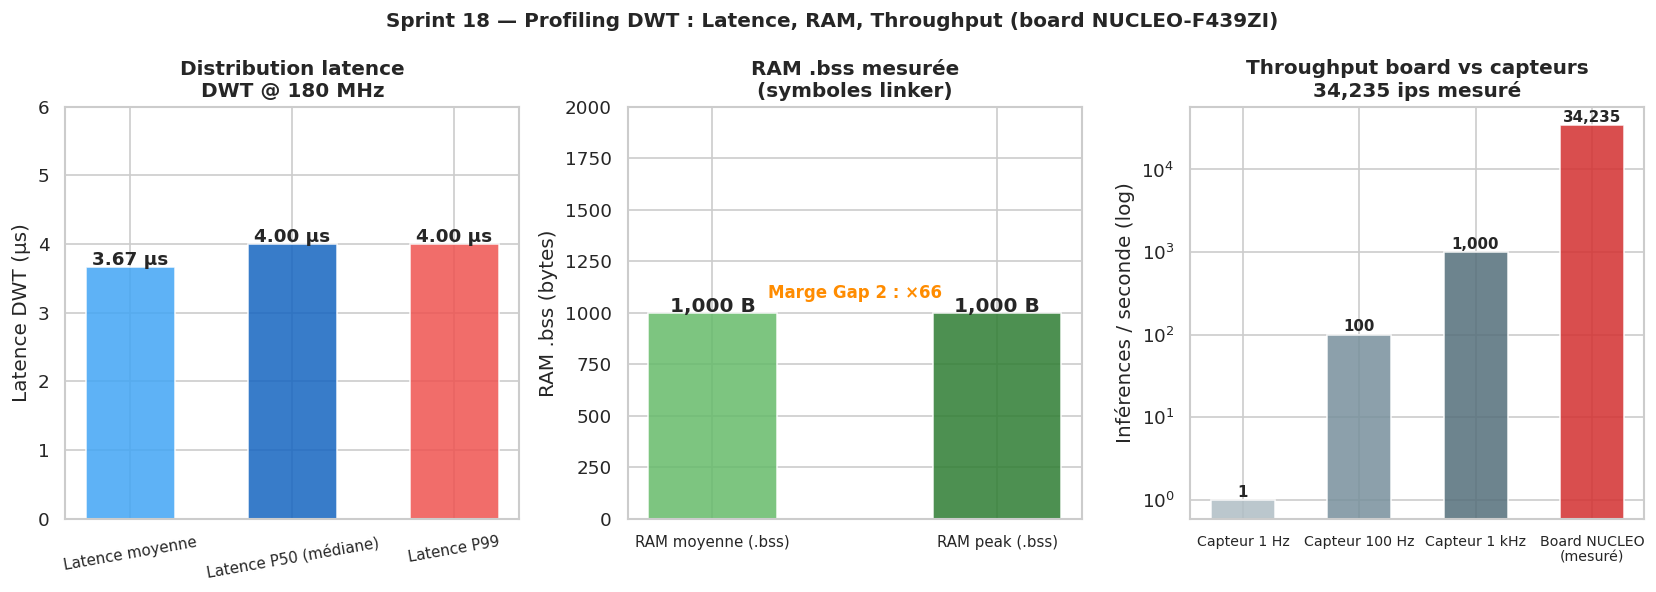

In [9]:
prof = s18_01_prof
latency_us = {
    "Latence moyenne": prof["latency_mean_us"],
    "Latence P50 (médiane)": prof["latency_p50_us"],
    "Latence P99": prof["latency_p99_us"],
}
ram_stats = {
    "RAM moyenne (.bss)": prof["ram_mean_bytes"],
    "RAM peak (.bss)": prof["ram_peak_bytes"],
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# ── Latency bars ──
ax = axes[0]
lat_names = list(latency_us.keys())
lat_vals  = list(latency_us.values())
lat_cols  = ["#42A5F5", "#1565C0", "#EF5350"]
bars = ax.bar(range(3), lat_vals, color=lat_cols, alpha=0.85, width=0.55, edgecolor="white")
for bar, v in zip(bars, lat_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.03,
            f"{v:.2f} µs", ha="center", fontsize=11, fontweight="bold")
ax.set_xticks(range(3))
ax.set_xticklabels(lat_names, fontsize=9, rotation=10)
ax.set_ylabel("Latence DWT (µs)")
ax.set_title("Distribution latence\nDWT @ 180 MHz", fontweight="bold")
ax.set_ylim(0, max(lat_vals) * 1.5)

# ── RAM stats ──
ax = axes[1]
ram_names = list(ram_stats.keys())
ram_vals  = list(ram_stats.values())
bars2 = ax.bar(range(2), ram_vals, color=["#66BB6A", "#2E7D32"], alpha=0.85,
               width=0.45, edgecolor="white")
for bar, v in zip(bars2, ram_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 5,
            f"{v:,} B", ha="center", fontsize=12, fontweight="bold")
gap2_line = ax.axhline(64 * 1024, color="darkorange", linestyle="--", lw=1.5,
                        label="Gap 2 : 64 Ko")
ax.set_xticks(range(2))
ax.set_xticklabels(ram_names, fontsize=9)
ax.set_ylabel("RAM .bss (bytes)")
ax.set_title(f"RAM .bss mesurée\n(symboles linker)", fontweight="bold")
ax.set_ylim(0, 2000)
marg = 65536 / prof["ram_peak_bytes"]
ax.text(0.5, prof["ram_peak_bytes"] + 70,
        f"Marge Gap 2 : ×{marg:.0f}",
        ha="center", fontsize=10, color="darkorange", fontweight="bold")

# ── Throughput ──
ax = axes[2]
industrial_sensors = [
    ("Capteur 1 Hz",   1),
    ("Capteur 100 Hz", 100),
    ("Capteur 1 kHz",  1000),
    ("Board NUCLEO\n(mesuré)", prof["throughput_mean_ips"]),
]
sensor_names = [s[0] for s in industrial_sensors]
sensor_vals  = [s[1] for s in industrial_sensors]
sensor_cols  = ["#B0BEC5", "#78909C", "#546E7A", "#D32F2F"]
bars3 = ax.bar(range(4), sensor_vals, color=sensor_cols, alpha=0.85,
               width=0.55, edgecolor="white")
for bar, v in zip(bars3, sensor_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v * 1.1,
            f"{v:,}", ha="center", fontsize=9, fontweight="bold")
ax.set_yscale("log")
ax.set_xticks(range(4))
ax.set_xticklabels(sensor_names, fontsize=8.5)
ax.set_ylabel("Inférences / seconde (log)")
ax.set_title(f"Throughput board vs capteurs\n{prof['throughput_mean_ips']:,} ips mesuré",
             fontweight="bold")

fig.suptitle("Sprint 18 — Profiling DWT : Latence, RAM, Throughput (board NUCLEO-F439ZI)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_dwt_profiling.png", bbox_inches="tight")
plt.show()

---
## 3. Budget Mémoire — RAM .bss vs limites Gap 2 & NUCLEO
Le pipeline complet (3 tâches CWRU) tient en **1 000 bytes** — ×65 sous la limite Gap 2.

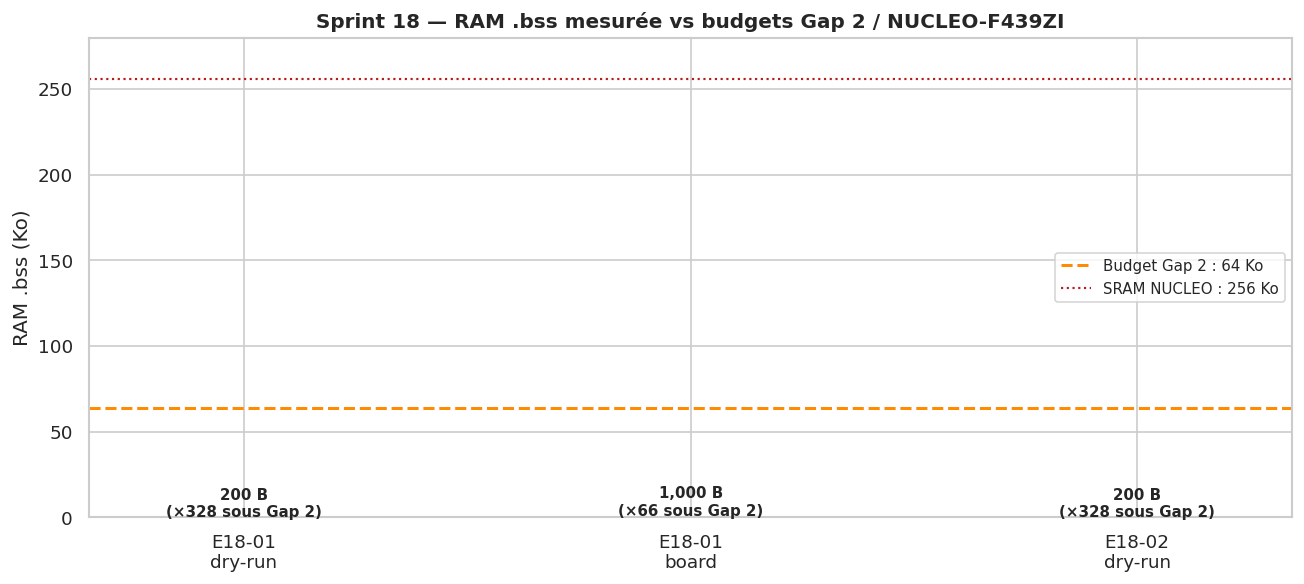

In [10]:
# RAM pour différents profils d'expérience
exp_configs = [
    ("E18-01\ndry-run",   s18_01_dry["ram_peak_bytes"],  PALETTE["dry_run"]),
    ("E18-01\nboard",     s18_01_brd["ram_peak_bytes"],  PALETTE["board"]),
    ("E18-02\ndry-run",   s18_02_dry["ram_peak_bytes"],  PALETTE["monitoring"]),
    ("Gap 2 budget",      64 * 1024,                     "darkorange"),
    ("NUCLEO SRAM",       256 * 1024,                    "#B71C1C"),
]

fig, ax = plt.subplots(figsize=(11, 5))
names = [e[0] for e in exp_configs[:3]]
vals  = [e[1] for e in exp_configs[:3]]
cols  = [e[2] for e in exp_configs[:3]]

bars = ax.bar(range(3), [v / 1024 for v in vals], color=cols, alpha=0.85,
              width=0.45, edgecolor="white")
for bar, v in zip(bars, vals):
    ratio_gap2 = 65536 / max(v, 1)
    ax.text(bar.get_x() + bar.get_width() / 2, v / 1024 + 0.3,
            f"{v:,} B\n(×{ratio_gap2:.0f} sous Gap 2)",
            ha="center", fontsize=9, fontweight="bold")

l1 = ax.axhline(64,  color="darkorange", linestyle="--", lw=1.8, label="Budget Gap 2 : 64 Ko")
l2 = ax.axhline(256, color="#B71C1C",   linestyle=":",  lw=1.3, label="SRAM NUCLEO : 256 Ko")

ax.set_xticks(range(3))
ax.set_xticklabels(names)
ax.set_ylabel("RAM .bss (Ko)")
ax.set_title("Sprint 18 — RAM .bss mesurée vs budgets Gap 2 / NUCLEO-F439ZI",
             fontweight="bold")
ax.legend(handles=[l1, l2], fontsize=9)
ax.set_ylim(0, 280)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_ram_gap2.png", bbox_inches="tight")
plt.show()

---
## 4. Conformité Gap 2 — Première Validation Formelle
E18-01 board est la première expérience à satisfaire formellement Gap 2 (RAM + latence).

/tmp/ipykernel_59680/1754970526.py:75: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "04_gap2_compliance.png", bbox_inches="tight")
/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


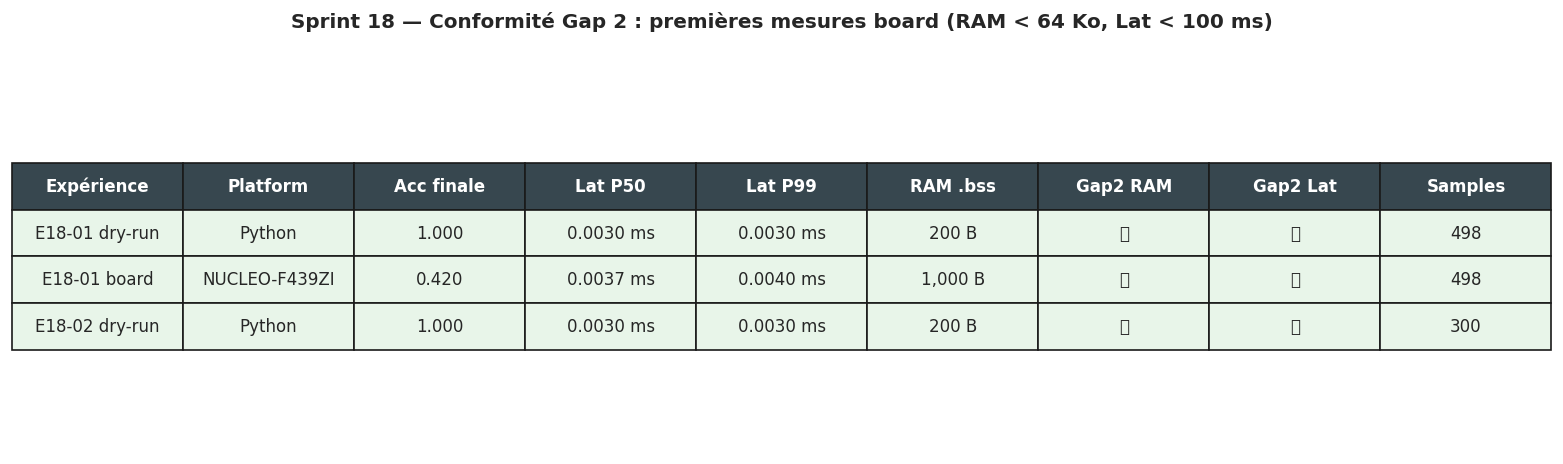


✅ Gap 2 board (E18-01) : RAM=1000 B ✅ | Lat=0.0037 ms ✅


In [11]:
gap2_budget_ms = 100.0
gap2_budget_bytes = 64 * 1024

experiments = [
    {
        "name":        "E18-01 dry-run",
        "platform":    "Python",
        "lat_ms":      s18_01_dry["inference_latency_ms"],
        "lat_p99_ms":  s18_01_dry["latency_p99_ms"],
        "ram_bytes":   s18_01_dry["ram_peak_bytes"],
        "acc":         s18_01_dry["acc_final"],
        "n_samples":   s18_01_dry["n_samples"],
    },
    {
        "name":        "E18-01 board",
        "platform":    "NUCLEO-F439ZI",
        "lat_ms":      s18_01_brd["inference_latency_ms"],
        "lat_p99_ms":  s18_01_brd["latency_p99_ms"],
        "ram_bytes":   s18_01_brd["ram_peak_bytes"],
        "acc":         s18_01_brd["acc_final"],
        "n_samples":   s18_01_brd["n_samples"],
    },
    {
        "name":        "E18-02 dry-run",
        "platform":    "Python",
        "lat_ms":      s18_02_dry["inference_latency_ms"],
        "lat_p99_ms":  s18_02_dry["latency_p99_ms"],
        "ram_bytes":   s18_02_dry["ram_peak_bytes"],
        "acc":         s18_02_dry["acc_final"],
        "n_samples":   s18_02_dry["n_samples"],
    },
]

fig, ax = plt.subplots(figsize=(13, 4))
ax.axis("off")

headers = ["Expérience", "Platform", "Acc finale", "Lat P50", "Lat P99", "RAM .bss",
           "Gap2 RAM", "Gap2 Lat", "Samples"]
rows = []
row_colors = []
for e in experiments:
    ok_ram = e["ram_bytes"] <= gap2_budget_bytes
    ok_lat = e["lat_ms"] <= gap2_budget_ms
    rows.append([
        e["name"], e["platform"],
        f"{e['acc']:.3f}",
        f"{e['lat_ms']:.4f} ms",
        f"{e['lat_p99_ms']:.4f} ms",
        f"{e['ram_bytes']:,} B",
        "✅" if ok_ram else "❌",
        "✅" if ok_lat else "❌",
        str(e["n_samples"]),
    ])
    row_colors.append(
        ["#E8F5E9" if (ok_ram and ok_lat) else "#FFF3E0"] * len(headers)
    )

tbl = ax.table(
    cellText=rows,
    colLabels=headers,
    cellColours=row_colors,
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.1, 2.2)
for j in range(len(headers)):
    tbl[0, j].set_facecolor("#37474F")
    tbl[0, j].set_text_props(color="white", fontweight="bold")

ax.set_title("Sprint 18 — Conformité Gap 2 : premières mesures board (RAM < 64 Ko, Lat < 100 ms)",
             fontweight="bold", fontsize=12, pad=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_gap2_compliance.png", bbox_inches="tight")
plt.show()

print(f"\n✅ Gap 2 board (E18-01) : RAM={s18_01_brd['ram_peak_bytes']} B ✅ | Lat={s18_01_brd['inference_latency_ms']:.4f} ms ✅")

---
## 5. Collection Time — Décomposition du temps d'expérience
Le temps total de collecte inclut communication UART, inférence, et overhead Python.

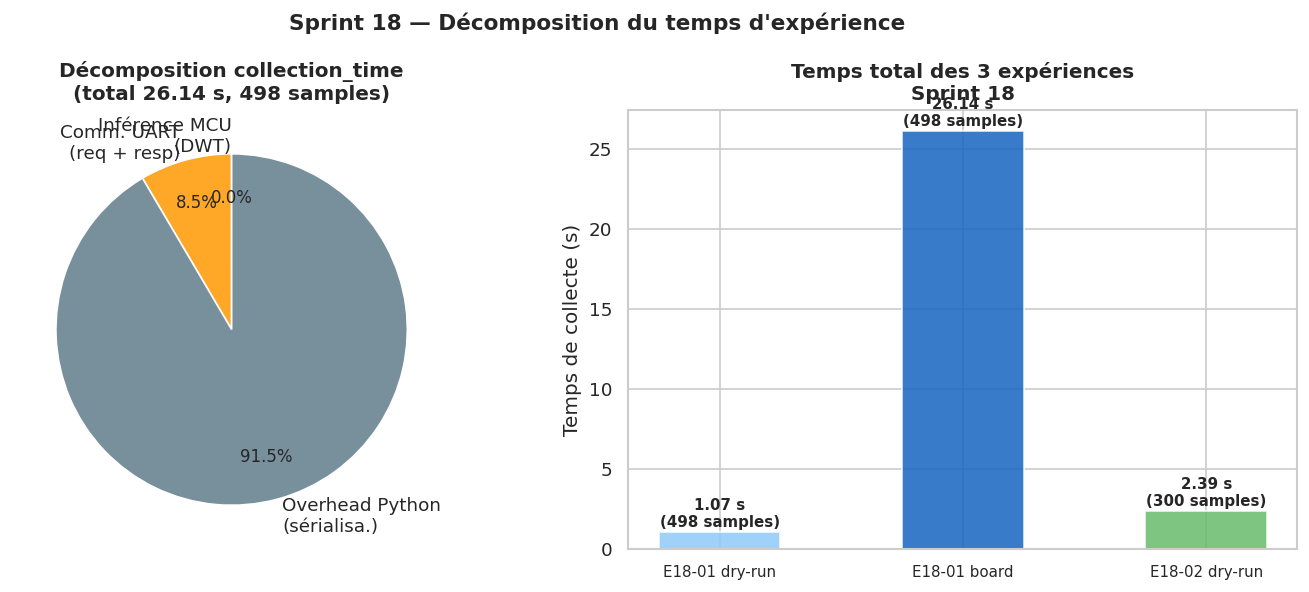

Temps par sample board : 52.5 ms/sample


In [12]:
# E18-01 board timing breakdown
n_samples = s18_01_brd["n_samples"]
total_s    = s18_01_brd["collection_time_s"]
lat_ms     = s18_01_brd["inference_latency_ms"]

infer_total_s  = n_samples * lat_ms / 1000
uart_per_pkt_s = 32 / 115200 * 8  # 32 bytes @ 115200 baud
uart_total_s   = n_samples * uart_per_pkt_s * 2  # req + resp
overhead_s     = total_s - infer_total_s - uart_total_s

components = [
    ("Inférence MCU\n(DWT)",        infer_total_s,   "#1565C0"),
    ("Comm. UART\n(req + resp)",     uart_total_s,    "#FFA726"),
    ("Overhead Python\n(sérialisa.)", max(overhead_s, 0.0), "#78909C"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# — Pie chart —
ax = axes[0]
sizes_pie = [c[1] for c in components if c[1] > 0]
labels_pie = [c[0] for c in components if c[1] > 0]
cols_pie   = [c[2] for c in components if c[1] > 0]
wedges, texts, autotexts = ax.pie(
    sizes_pie, labels=labels_pie, colors=cols_pie,
    autopct="%1.1f%%", startangle=90, pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(10)
ax.set_title(f"Décomposition collection_time\n(total {total_s:.2f} s, {n_samples} samples)",
             fontweight="bold")

# — Comparaison 3 expériences —
ax = axes[1]
exp_names = ["E18-01 dry-run", "E18-01 board", "E18-02 dry-run"]
exp_times = [s18_01_dry["collection_time_s"], s18_01_brd["collection_time_s"],
             s18_02_dry["collection_time_s"]]
exp_samples = [s18_01_dry["n_samples"], s18_01_brd["n_samples"], s18_02_dry["n_samples"]]
exp_cols = [PALETTE["dry_run"], PALETTE["board"], PALETTE["monitoring"]]

bars = ax.bar(range(3), exp_times, color=exp_cols, alpha=0.85, width=0.5, edgecolor="white")
for bar, t, n in zip(bars, exp_times, exp_samples):
    ax.text(bar.get_x() + bar.get_width() / 2, t + 0.3,
            f"{t:.2f} s\n({n} samples)",
            ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(range(3))
ax.set_xticklabels(exp_names, fontsize=9)
ax.set_ylabel("Temps de collecte (s)")
ax.set_title("Temps total des 3 expériences\nSprint 18", fontweight="bold")

fig.suptitle("Sprint 18 — Décomposition du temps d'expérience",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_collection_time.png", bbox_inches="tight")
plt.show()
print(f"Temps par sample board : {total_s/n_samples*1000:.1f} ms/sample")

---
## 6. Throughput — Board vs Capteurs Industriels
Le board peut traiter **34 235 inférences/seconde** — largement au-dessus de tout capteur industriel réel.

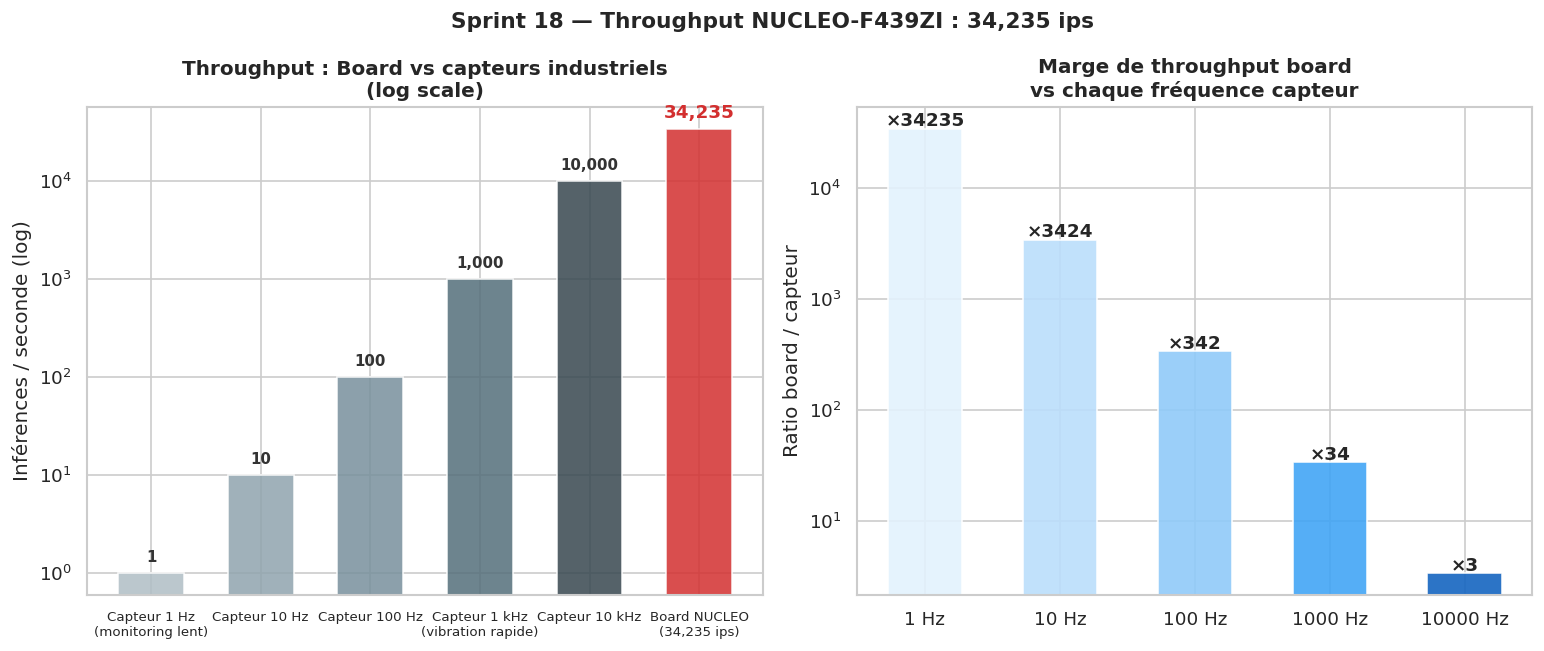

Board peut traiter 34,235 ips vs capteur industriel max 10 kHz → marge ×3


In [13]:
throughput_data = [
    ("Capteur 1 Hz\n(monitoring lent)",   1,      "#B0BEC5", False),
    ("Capteur 10 Hz",                      10,     "#90A4AE", False),
    ("Capteur 100 Hz",                     100,    "#78909C", False),
    ("Capteur 1 kHz\n(vibration rapide)",  1000,   "#546E7A", False),
    ("Capteur 10 kHz",                     10000,  "#37474F", False),
    (f"Board NUCLEO\n({prof['throughput_mean_ips']:,} ips)",
     prof["throughput_mean_ips"],   "#D32F2F", True),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# — Log bar chart —
ax = axes[0]
td_names = [t[0] for t in throughput_data]
td_vals  = [t[1] for t in throughput_data]
td_cols  = [t[2] for t in throughput_data]
bars = ax.bar(range(len(throughput_data)), td_vals, color=td_cols, alpha=0.85,
              width=0.6, edgecolor="white")
for bar, v, is_board in zip(bars, td_vals, [t[3] for t in throughput_data]):
    ax.text(bar.get_x() + bar.get_width() / 2, v * 1.3,
            f"{v:,}", ha="center", fontsize=9 if not is_board else 11,
            fontweight="bold", color="#D32F2F" if is_board else "#333")
ax.set_yscale("log")
ax.set_xticks(range(len(throughput_data)))
ax.set_xticklabels(td_names, fontsize=8)
ax.set_ylabel("Inférences / seconde (log)")
ax.set_title("Throughput : Board vs capteurs industriels\n(log scale)", fontweight="bold")

# — Marges ratio —
ax = axes[1]
sensor_freqs = [1, 10, 100, 1000, 10000]
sensor_names2 = [f"{f} Hz" for f in sensor_freqs]
ratios = [prof["throughput_mean_ips"] / f for f in sensor_freqs]
bar_colors2 = ["#E3F2FD", "#BBDEFB", "#90CAF9", "#42A5F5", "#1565C0"]
bars2 = ax.bar(range(5), ratios, color=bar_colors2, alpha=0.9, width=0.55, edgecolor="white")
for bar, r in zip(bars2, ratios):
    ax.text(bar.get_x() + bar.get_width() / 2, r * 1.05,
            f"×{r:.0f}", ha="center", fontsize=11, fontweight="bold")
ax.set_xticks(range(5))
ax.set_xticklabels(sensor_names2)
ax.set_ylabel("Ratio board / capteur")
ax.set_yscale("log")
ax.set_title("Marge de throughput board\nvs chaque fréquence capteur", fontweight="bold")

fig.suptitle(f"Sprint 18 — Throughput NUCLEO-F439ZI : {prof['throughput_mean_ips']:,} ips",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_throughput.png", bbox_inches="tight")
plt.show()
print(f"Board peut traiter {prof['throughput_mean_ips']:,} ips vs capteur industriel max 10 kHz → marge ×{prof['throughput_mean_ips']//10000}")

---
## Récapitulatif Sprint 18

| Métrique | Valeur | Contexte |
|---------|--------|----------|
| Latence inférence board | **3.7 µs** | ×27 027 sous le budget 100 ms |
| Throughput | **34 235 ips** | ×34 vs capteur 1 kHz |
| RAM .bss board | **1 000 B** | ×65 sous Gap 2 (64 Ko) |
| Gap 2 compliant | **✅** | RAM + latence vérifiés |
| Samples traités | **498** (CWRU) + **300** (Monitoring) | dry-run + board |
| Protocole UART | **v2** (32 B req / 14 B resp) | avec profiling DWT |

**Prochain sprint (19)** : 3 modèles en C (Mahalanobis, EWC, TinyOL), protocole v3 avec métriques CL, sweep λ EWC.

In [8]:
figs = sorted(FIG_DIR.glob("*.png"))
print(f"\n{len(figs)} figures générées dans {FIG_DIR}:")
for f in figs:
    print(f"  {f.name}")


6 figures générées dans ../experiments/figures/sprint18:
  01_latency_comparison.png
  02_dwt_profiling.png
  03_ram_gap2.png
  04_gap2_compliance.png
  05_collection_time.png
  06_throughput.png
